In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')

In [5]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [11]:
df.shape

(9704, 11)

In [13]:
# normalize the names of columns

df.columns = df.columns.str.lower().str.replace(' ', '_')

In [15]:
# Select the desired columns
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

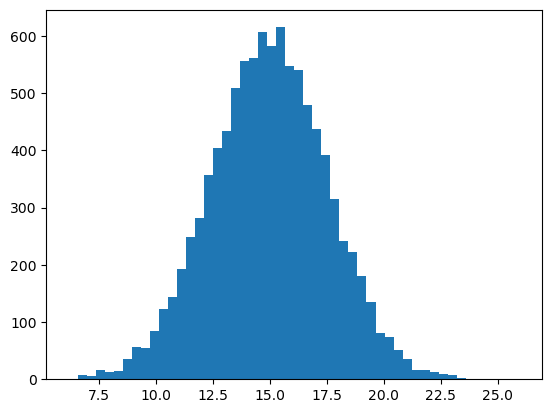

In [27]:
plt.hist(df.fuel_efficiency_mpg, bins=50)
plt.show()

`fuel_efficiency_mpg` seems to have a normal distribution.

#### Question 1
There's one column with missing values. What is it?

`horsepower` has 708 missing values in the dataframe.

In [31]:
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

#### Question 2
What's the median (50% percentile) for variable 'horsepower'?


Answer: 149

In [34]:
df['horsepower'].median()

149.0

#### Prepare and split the dataset

- Shuffle the dataset (the filtered one you created above), use seed 42.
- Split your data in train/val/test sets, with 60%/20%/20% distribution.

In [36]:
n = len(df)
idx= np.arange(n)

In [38]:
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [40]:
np.random.seed(42)
np.random.shuffle(idx)

In [42]:
n_train, n_val, n_test

(5824, 1940, 1940)

In [91]:
# Taking the first n_train observation for df_train
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)

df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)

df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

In [85]:
df_train.shape[0], df_val.shape[0], df_test.shape[0]

(5824, 1940, 1940)

In [93]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,220,144.0,2535.887591,2009,16.642943
1,160,141.0,2741.170484,2019,16.298377
2,230,155.0,2471.880237,2017,18.591822
3,150,206.0,3748.164469,2015,11.818843
4,300,111.0,2135.716359,2006,19.402209


In [95]:
# Separate target variable from the df 

y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

In [97]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [99]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,220,144.0,2535.887591,2009
1,160,141.0,2741.170484,2019
2,230,155.0,2471.880237,2017
3,150,206.0,3748.164469,2015
4,300,111.0,2135.716359,2006


#### Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 2 decimal digits using round(score, 2)
- Which option gives better RMSE?

In [101]:
df_train.isnull().sum()

engine_displacement      0
horsepower             429
vehicle_weight           0
model_year               0
dtype: int64

The 'horsepower' columns from training data set containing missing values so we will need to deal with the missing values. 
- Two options are:
- 1. Fill the missing with 0
  2. fill the missing with the mean of horsepower.

In [62]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [64]:
def prepare_X(df, fillna_value):
    df = df.fillna(fillna_value)
    X = df.values
    return X

In [66]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

##### *Option 1*: Fill the missing value with 0

In [68]:
df_train_o1 = df_train.copy()
df_train_o1 = df_train_o1.fillna(0)

In [70]:
X_train_o1 = prepare_X(df_train, fillna_value = 0)

In [104]:
w0, w = train_linear_regression(X_train_o1, y_train)

X_val = df_val.values
y_pred = w0 + X_val.dot(w)

float(round(rmse(y_val, y_pred),2))

0.5

##### *Option 2*: Fill the missing value with the mean

In [106]:
mean_value = df['fuel_efficiency_mpg'].mean()
X_train_o2 = prepare_X(df_train, fillna_value = mean_value)

In [108]:
w0, w = train_linear_regression(X_train_o2, y_train)

X_val = df_val.values
y_pred = w0 + X_val.dot(w)

float(round(rmse(y_val, y_pred),2))

0.49

RMSE of option 2 is slightly lower so it is a better method to use.

#### Question 4
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 2 decimal digits.
- Which r gives the best RMSE?

In [81]:
def train_linear_regression_reg(X, y, r=0.01):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [110]:
X_train = prepare_X(df_train, fillna_value=0)
X_val = prepare_X(df_val, fillna_value = 0)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    print(r, float(round(rmse(y_val, y_pred),2)))

0 0.52
0.01 0.52
0.1 0.52
1 0.52
5 0.52
10 0.52
100 0.52


All r produces the same RMSE score so use the smallest value 0.

#### Question 5
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

In [112]:
rmses = []

for seed in range(10):
    n = len(df)
    idx= np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)
    df_shuffled = df.iloc[idx]

    df_train = df_shuffled[:n_train].copy().reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy().reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].copy().reset_index(drop=True)

    y_train = df_train['fuel_efficiency_mpg']
    y_val = df_val['fuel_efficiency_mpg']
    y_test = df_test['fuel_efficiency_mpg']

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X(df_train, fillna_value=0)
    X_val = prepare_X(df_val, fillna_value = 0)
    
    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)

    result = rmse(y_val, y_pred)
    print(seed, float(round(result,2)))

    rmses.append(result)
    

0 0.52
1 0.52
2 0.52
3 0.52
4 0.51
5 0.53
6 0.53
7 0.51
8 0.51
9 0.51


In [114]:
# Calculate the standard deviation of all the RMSE score
float(round(np.std(rmses),3))

0.007

#### Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

In [116]:
n = len(df)
idx= np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)
df_shuffled = df.iloc[idx]

df_train = df_shuffled[:n_train].copy().reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].copy().reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].copy().reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [118]:
df_train_full = pd.concat([df_train, df_val])

In [120]:
# Combine the y_train and y_val 
y_train_full = np.concatenate([y_train, y_val])

In [122]:
X_train_full = prepare_X(df_train_full, fillna_value=0)
w0, w = train_linear_regression_reg(X_train_full, y_train_full, r=0.001)

X_test = prepare_X(df_test, fillna_value=0)
y_pred = w0 + X_test.dot(w)
rmse(y_test, y_pred)

0.5156261299202296